# Per-bit intensity profile across FOVs, and comparison to MERlin's own optimized scale factors

Follow-up to the WAI investigation (`01_test_weighted_average_intensity.ipynb`):
instead of averaging the 16 barcode bits' per-FOV mean intensity into one WAI
scalar, keep each bit's own per-FOV mean intensity separate. This checks two
things:

1. Does every bit's per-FOV intensity profile have roughly the same *shape*
   across FOVs (as WAI's single averaged profile suggested)? If so, an affine
   rescaling of each bit's profile -- `y_scaled(bitX, i) =
   Factor_bitX * (y_original(bitX, i) - min(y_original(bitX)))` -- should
   bring all 16 profiles into close overlap.
2. How does the per-bit `Factor_bitX` needed to do that compare to the
   per-bit scale factor MERlin's own `Optimize` task converges to (used
   directly by `Decode` to normalize each bit before barcode matching)? Both
   are, in different ways, "how much does this bit's raw intensity need to
   be rescaled to be comparable to the others" -- if the two agree, a
   perfectly-scaled per-bit profile computed from raw images *before*
   decoding could stand in for (or sanity-check) MERlin's own optimization.

**Dataset**: `BC555_sample_05/epi`, same z-plane resolution and bit lookup
as `01_test_weighted_average_intensity.ipynb` (reused via
`MERci.analysis.fov.resolve_barcode_bit_lookup`, factored out for this
purpose -- see that function's docstring for the round_bit_color_map.csv
cross-reference it replaces).

**Images produced**:
- per-bit mean intensity vs. FOV index, 16 lines (one per bit)
- the same 16 profiles after the affine rescaling, to check how well they overlay
- `Factor_bitX` (inverted, `1/Factor_bitX`, so both axes increase with bit
  brightness) vs. MERlin's own converged per-bit scale factor

Follows `NOTEBOOK_GUIDELINES.md`: calculation cached under
`analysis/cache/test_intensity_vs_bit/`, skip already-done FOVs on rerun,
`ProgressReporter` progress; display cells separate, every figure saved to
`analysis/figures/`.

## 1 — Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent   # MERci/

sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config          import ExperimentConfig
from MERci.common.metadata        import ExperimentMetadata
from MERci.common.io              import read_image_frames
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.analysis.fov           import resolve_barcode_bit_lookup
from MERci.progress_display       import ProgressReporter
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "test_intensity_vs_bit"
print(f"MERCI_DIR : {MERCI_DIR}")

MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci


## 2 — Parameters

In [2]:
# This is a test/investigation notebook (NOTEBOOK_GUIDELINES.md's "validation
# notebooks for a new feature" case under notebooks/tests/) -- it analyzes an
# EXTERNAL dataset, not the experiment this MERci clone is deployed into, so
# SAMPLE_DIR is set explicitly rather than auto-detected from parent dirs.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi")
IMAGE_SUFFIX = ".zarr"

N_BARCODE_BITS = 16

Z_PLANE = None   # None = auto-pick the middle z of the bits round's frame table (section 4);
                 # same auto-pick as 01_test_weighted_average_intensity.ipynb for a like-for-like comparison.

FORCE_RECOMPUTE = False

# MERlin's own converged per-bit scale factors (section 8): Decode's real
# `optimize_task` per merlin_analysis_BC555_sample_05.yaml -- the last
# iteration in the chained OptimizeIteration sequence (Optimize01 -> ... ->
# Optimize10, each depending on the previous one's result).
MERLIN_OPTIMIZE_DIR = SAMPLE_DIR / "merlin" / "output" / "Optimize10"

PLOT_TITLE_FONTSIZE  = 14
PLOT_LABEL_FONTSIZE  = 12
PLOT_TICK_FONTSIZE   = 11
PLOT_LEGEND_FONTSIZE = 9

print(f"SAMPLE_DIR          : {SAMPLE_DIR}")
print(f"MERLIN_OPTIMIZE_DIR : {MERLIN_OPTIMIZE_DIR}")

SAMPLE_DIR          : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi
MERLIN_OPTIMIZE_DIR : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/merlin/output/Optimize10


## 3 — Resolve dataset geometry

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir       = SAMPLE_DIR / "data",
    metadata_dir   = SAMPLE_DIR / "metadata",
    analysis_dir   = SAMPLE_DIR / "analysis",
    settings_dir   = SAMPLE_DIR / "settings",
    round_info_csv = SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt  = SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix   = IMAGE_SUFFIX,
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

# NOTEBOOK_GUIDELINES.md #2: cache under analysis/cache/<notebook_name>/.
CACHE_DIR = config.analysis_dir / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / "intensity_per_fov_per_bit.csv"

# NOTEBOOK_GUIDELINES.md #6: figures under figures/MERci/tests/optimization_fov_selection/{NOTEBOOK_NAME}/.
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="optimization_fov_selection")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

round_info = pd.read_csv(config.round_info_csv)

print(f"Sample name: {sample_name}")
print(f"FOVs       : {meta.n_fovs}")
print(f"Cache      : {CACHE_PATH}")
print(f"Figures    : {FIGURES_DIR}")

Sample name: BC555_sample_05
FOVs       : 476
Cache      : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit.csv
Figures    : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/figures


## 4 — Resolve the per-bit lookup

Reuses `MERci.analysis.fov.resolve_barcode_bit_lookup` (relocated from
`01_test_weighted_average_intensity.ipynb`'s own section 4 so this second
notebook doesn't duplicate the round_bit_color_map.csv/round_info.csv
cross-reference).

In [4]:
bit_lookup, bits_series_by_round, Z_PLANE = resolve_barcode_bit_lookup(
    config, meta, round_info, n_barcode_bits=N_BARCODE_BITS, z_plane=Z_PLANE,
)

print(f"Z_PLANE (chosen): {Z_PLANE}")
for bit, (rid, fidx) in sorted(bit_lookup.items()):
    print(f"  bit {bit:2d}: round {rid}, frame {fidx}")

Z_PLANE (chosen): 13
  bit  1: round 1, frame 37
  bit  2: round 1, frame 38
  bit  3: round 2, frame 37
  bit  4: round 2, frame 38
  bit  5: round 3, frame 37
  bit  6: round 3, frame 38
  bit  7: round 4, frame 37
  bit  8: round 4, frame 38
  bit  9: round 5, frame 37
  bit 10: round 5, frame 38
  bit 11: round 6, frame 37
  bit 12: round 6, frame 38
  bit 13: round 7, frame 37
  bit 14: round 7, frame 38
  bit 15: round 8, frame 37
  bit 16: round 8, frame 38


## 5 — Calculation: per-FOV, per-bit mean intensity

**Calculation cell** (`NOTEBOOK_GUIDELINES.md` #1/#2/#3/#4): for every FOV
and every barcode bit, reads that bit's frame at `Z_PLANE` (true partial
read via `read_image_frames`) and records its mean pixel intensity -- long
format (`fov_id`, `bit`, `mean_intensity`), one row per (FOV, bit). Cached
to `analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit.csv`; a
FOV already fully cached (all `N_BARCODE_BITS` bits present) is skipped on
rerun unless `FORCE_RECOMPUTE`.

In [5]:
if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    cache_df = pd.read_csv(CACHE_PATH)
else:
    cache_df = pd.DataFrame(columns=["fov_id", "bit", "mean_intensity"])

done_fovs = {fov_id for fov_id, n in cache_df.groupby("fov_id").size().items() if n == N_BARCODE_BITS}
all_fov_ids  = sorted(meta.fovs)
todo_fov_ids = [f for f in all_fov_ids if f not in done_fovs]

print(f"{len(done_fovs)} / {len(all_fov_ids)} FOV(s) already cached; computing {len(todo_fov_ids)} more.")

new_rows = []
reporter = ProgressReporter(total=len(todo_fov_ids), label="Computing per-FOV, per-bit intensity")
for fov_id in todo_fov_ids:
    for bit, (round_id, frame_idx) in bit_lookup.items():
        series = bits_series_by_round[round_id]
        path   = series.resolve_path(fov_id, config.image_suffix)
        frame  = read_image_frames(path, [frame_idx])[0]
        new_rows.append({"fov_id": fov_id, "bit": bit, "mean_intensity": float(frame.mean())})
    reporter.update()
reporter.done()

if new_rows:
    cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
    cache_df = cache_df.drop_duplicates(subset=["fov_id", "bit"]).sort_values(["fov_id", "bit"]).reset_index(drop=True)
    cache_df.to_csv(CACHE_PATH, index=False)

wide = cache_df.pivot(index="fov_id", columns="bit", values="mean_intensity").sort_index()
print(f"Intensity computed for {wide.shape[0]} FOV(s) x {wide.shape[1]} bit(s). Cache: {CACHE_PATH}")

0 / 476 FOV(s) already cached; computing 476 more.


Computing per-FOV, per-bit intensity: [------------------------] 1/476 (  0.2%)  elapsed 2s  ETA 12m 19s          

Computing per-FOV, per-bit intensity: [------------------------] 2/476 (  0.4%)  elapsed 3s  ETA 11m 18s          

Computing per-FOV, per-bit intensity: [------------------------] 3/476 (  0.6%)  elapsed 4s  ETA 10m 46s          

Computing per-FOV, per-bit intensity: [------------------------] 4/476 (  0.8%)  elapsed 6s  ETA 10m 53s          

...

Computing per-FOV, per-bit intensity: [#######################-] 474/476 ( 99.6%)  elapsed 11m 44s  ETA 3s          

Computing per-FOV, per-bit intensity: [#######################-] 475/476 ( 99.8%)  elapsed 11m 45s  ETA 1s          

Computing per-FOV, per-bit intensity: [########################] 476/476 (100.0%)  elapsed 11m 47s  ETA 0s          

Computing per-FOV, per-bit intensity: [########################] 476/476 (100.0%)  elapsed 11m 47s  ETA 0s          


Intensity computed for 476 FOV(s) x 16 bit(s). Cache: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/breast_cancer/experiments/BC555_sample_05/epi/analysis/cache/test_intensity_vs_bit/intensity_per_fov_per_bit.csv


## 6 — Per-bit mean intensity vs. FOV index

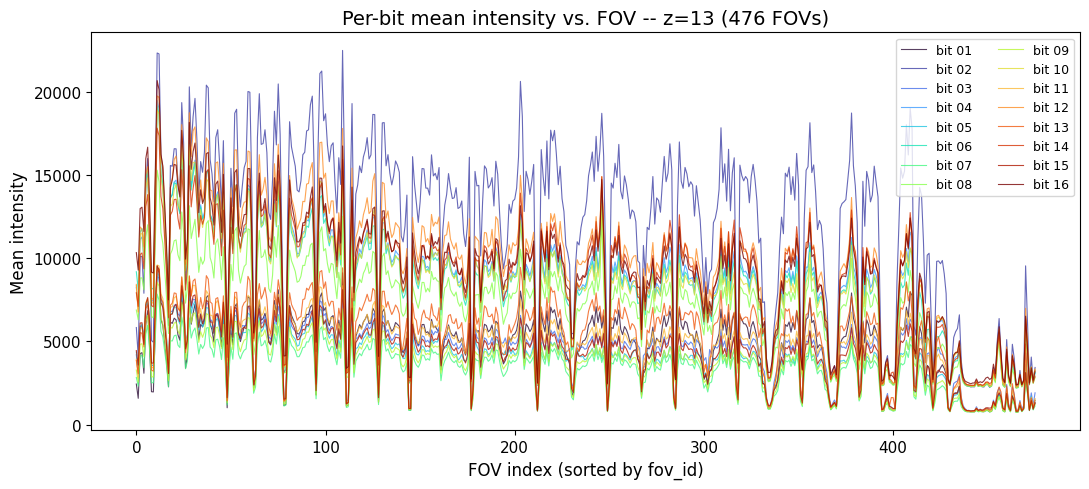

In [6]:
fov_index = np.arange(len(wide))
bits = sorted(wide.columns)
cmap = plt.cm.turbo
color_of = {b: cmap(i / max(len(bits) - 1, 1)) for i, b in enumerate(bits)}

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index, wide[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Mean intensity", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit mean intensity vs. FOV -- z={Z_PLANE} ({len(fov_index)} FOVs)", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_per_bit.png", dpi=150)
plt.show()

## 7 — Affine overlay: per-bit scaling factors

For each bit, subtract that bit's own minimum across FOVs
(`y - min(y)`), then find the single multiplicative `Factor_bitX` that best
overlays the min-subtracted profile onto a **consensus shape**: the average,
across all 16 bits, of each bit's own min-subtracted profile independently
rescaled to `[0, 1]` (`(y - min) / (max - min)`). `Factor_bitX` is then the
least-squares scale of the min-subtracted profile onto that consensus (no
intercept -- the subtraction already anchors it at 0):

`Factor_bitX = <(y_bitX - min_bitX), consensus> / <(y_bitX - min_bitX), (y_bitX - min_bitX)>`

which is exactly `y_scaled(bitX, i) = Factor_bitX * (y_original(bitX, i) -
min(y_original(bitX)))` as specified, with the consensus (rather than one
arbitrarily chosen bit) as the common target every profile is fit to.

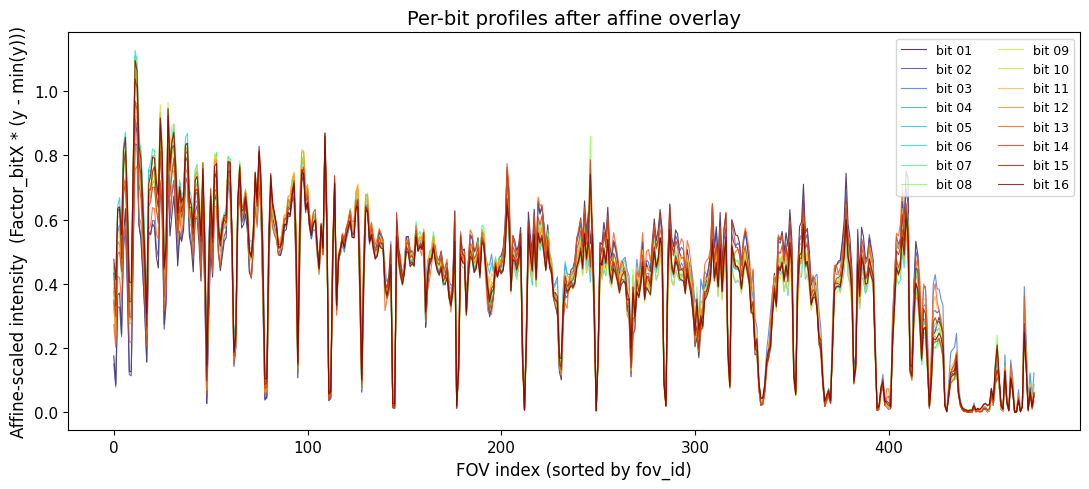

Factor_bitX:
1     0.000104
2     0.000042
3     0.000112
4     0.000064
5     0.000127
6     0.000067
7     0.000155
8     0.000083
9     0.000138
10    0.000066
11    0.000105
12    0.000055
13    0.000090
14    0.000063
15    0.000119
16    0.000060


In [7]:
min_per_bit = wide.min(axis=0)
range_per_bit = wide.max(axis=0) - min_per_bit
centered = wide.subtract(min_per_bit, axis=1)                       # y - min(y), per bit
normalized_01 = centered.divide(range_per_bit, axis=1)               # (y - min) / (max - min), per bit
consensus = normalized_01.mean(axis=1).values                        # average shape across all 16 bits

factor_per_bit = {}
for b in bits:
    y = centered[b].values
    factor_per_bit[b] = float(np.dot(y, consensus) / np.dot(y, y))
factor_series = pd.Series(factor_per_bit).sort_index()

scaled = centered.multiply(factor_series, axis=1)   # y_scaled(bitX, i) = Factor_bitX * (y - min(y))

fig, ax = plt.subplots(figsize=(11, 5))
for b in bits:
    ax.plot(fov_index, scaled[b].values, "-", lw=0.8, alpha=0.8, color=color_of[b], label=f"bit {b:02d}")
ax.set_xlabel("FOV index (sorted by fov_id)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Affine-scaled intensity  (Factor_bitX * (y - min(y)))", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Per-bit profiles after affine overlay", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
ax.legend(fontsize=PLOT_LEGEND_FONTSIZE, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.intensity_overlay.png", dpi=150)
plt.show()

print("Factor_bitX:")
print(factor_series.to_string())

## 8 — Compare to MERlin's own optimized scale factors

MERlin's `Decode` task (`merlin_analysis_BC555_sample_05.yaml`) uses
`Optimize10` -- the last in the chained `Optimize01 -> ... -> Optimize10`
`OptimizeIteration` sequence, each depending on the previous one's result.
Its `scale_factors.npy` (16 values, index *i* = bit *i+1*, confirmed against
`codebook_0_C3v1_codebook.csv`'s RS-column order via the data-organization
CSV's `bitNumber` column) is `nanmedian(refactor * previous_scale_factor)`
across that iteration's FOV fragments (`merlin/analysis/optimize.py`,
`OptimizeIteration.get_scale_factors`) -- the actual per-bit rescale MERlin
converged to before decoding.

`Factor_bitX` (section 7) and MERlin's scale factor move in *opposite*
directions with bit brightness: a bright bit has a large raw-intensity
range, so needs a *small* `Factor_bitX` to reach the ~[0,1] consensus scale,
while MERlin's scale factor for a bright bit is *larger* (it divides the
raw signal down to a common scale). `1/Factor_bitX` is plotted against
MERlin's scale factor so both axes increase with bit brightness, for a
directly interpretable comparison.

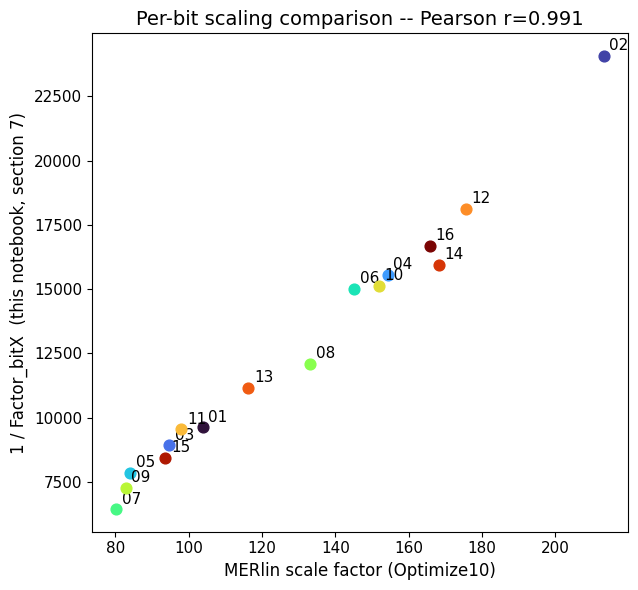

    Factor_bitX  1/Factor_bitX  merlin_scale_factor
1        0.0001      9622.9006             103.8476
2        0.0000     24068.6264             213.1545
3        0.0001      8917.6618              94.6972
4        0.0001     15561.3438             154.2823
5        0.0001      7857.8742              84.0162
6        0.0001     15011.8633             145.0782
7        0.0002      6437.2544              80.1644
8        0.0001     12094.6296             133.1816
9        0.0001      7266.7464              82.7678
10       0.0001     15128.5950             151.8815
11       0.0001      9534.5550              97.9998
12       0.0001     18123.9814             175.4937
13       0.0001     11147.8284             116.2236
14       0.0001     15947.7325             168.2566
15       0.0001      8425.8797              93.6160
16       0.0001     16688.6550             165.6545

Pearson r (1/Factor_bitX vs. MERlin scale factor): 0.9910


In [8]:
merlin_scale_factors = np.load(MERLIN_OPTIMIZE_DIR / "scale_factors.npy")
merlin_per_bit = pd.Series({i + 1: float(v) for i, v in enumerate(merlin_scale_factors)}).sort_index()

inv_factor_series = 1.0 / factor_series

comparison = pd.DataFrame({
    "Factor_bitX":            factor_series,
    "1/Factor_bitX":          inv_factor_series,
    "merlin_scale_factor":    merlin_per_bit,
})
r = np.corrcoef(comparison["1/Factor_bitX"], comparison["merlin_scale_factor"])[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
for b in bits:
    ax.scatter(comparison.loc[b, "merlin_scale_factor"], comparison.loc[b, "1/Factor_bitX"],
               color=color_of[b], s=60, zorder=3)
    ax.annotate(f"{b:02d}", (comparison.loc[b, "merlin_scale_factor"], comparison.loc[b, "1/Factor_bitX"]),
                fontsize=PLOT_TICK_FONTSIZE, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("MERlin scale factor (Optimize10)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("1 / Factor_bitX  (this notebook, section 7)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title(f"Per-bit scaling comparison -- Pearson r={r:.3f}", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.scale_factor_comparison.png", dpi=150)
plt.show()

print(comparison.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nPearson r (1/Factor_bitX vs. MERlin scale factor): {r:.4f}")